# Configuration

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import random

In [3]:
TICKER = "TSLA"

# Create DataFrame with TICKER

In [21]:
tesla = pd.read_csv(f"../data/features/{TICKER}_features.csv")
print(f"Size of {TICKER} dataset: {tesla.shape}")
tesla.tail()

Size of TSLA dataset: (1207, 135)


,date,open,high,low,close,volume,symbol,log_return,next_day_return,return_lag_1,...,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,vwap_5_scaled,price_to_vwap_scaled,obv_scaled,obv_ema_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
1202,2024-12-23,431.000000,434.510010,415.410004,430.600006,72698100,TSLA,0.022404,0.070991,-0.035257,...,-0.991649,-0.237916,-0.425982,2.647402,-0.584714,1.249207,1.250505,0.117043,-0.319123,0.687298
1203,2024-12-24,435.899994,462.779999,435.140015,462.279999,59551800,TSLA,0.070991,-0.017787,0.022404,...,-1.329250,-0.274356,-0.834958,2.563200,1.117838,1.264048,1.252393,0.793948,-0.653420,1.731414
1204,2024-12-26,465.160004,465.329987,451.019989,454.130005,76366400,TSLA,-0.017787,-0.050745,0.070991,...,-0.729346,-0.260246,-0.267188,2.582779,0.682551,1.245016,1.250512,-0.432885,0.317122,-0.513262
1205,2024-12-27,449.519989,450.000000,426.500000,431.660004,82666800,TSLA,-0.050745,-0.033569,-0.017787,...,-0.510392,-0.235408,-0.087805,2.573317,-0.274182,1.224414,1.245265,0.469019,1.021610,-0.302735
1206,2024-12-30,419.399994,427.000000,415.750000,417.410004,64941000,TSLA,-0.033569,NaN,-0.050745,...,-1.040499,-0.207558,-0.729145,2.600548,-0.998514,1.208229,1.238058,-0.613043,0.249155,-0.630714


# Visualize Time Series Split

In [48]:
'''
Generates training and testing indices on each time-series-split data

Args:
    data: dataset (or feature matrix) of a stock to split.
    n_splits: Number of folds.
    test_size: Size of each test set.
    gap: Number of samples to exclude between train and test (must be equal to test_size).

Returns:
    List of dicts with keys: (1) "fold": fold number, 0-based (2) "train_idx": training indices (3) "test_idx": testing indices
'''
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 90):
    assert test_size == gap, "gap must be equal to test size to avoid overlapping in test data"
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx,  
            "test_idx": test_idx,
        })
    return folds
# create time series split
folds = createTimeSeriesSplit(data=df)

In [49]:
def previewFold(folds: list):
    for k in folds:
        print("fold:", k["fold"], "\ntrain_idx", k["train_idx"][:20], "...", k["train_idx"][-20:], 
                        "\ntest_idex", k["test_idx"][:20], "...", k["test_idx"][-15:])
previewFold(folds)

fold: 0 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [647 648 649 650 651 652 653 654 655 656 657 658 659 660 661 662 663 664
 665 666] 
test_idex [757 758 759 760 761 762 763 764 765 766 767 768 769 770 771 772 773 774
 775 776] ... [832 833 834 835 836 837 838 839 840 841 842 843 844 845 846]
fold: 1 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [737 738 739 740 741 742 743 744 745 746 747 748 749 750 751 752 753 754
 755 756] 
test_idex [847 848 849 850 851 852 853 854 855 856 857 858 859 860 861 862 863 864
 865 866] ... [922 923 924 925 926 927 928 929 930 931 932 933 934 935 936]
fold: 2 
train_idx [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] ... [827 828 829 830 831 832 833 834 835 836 837 838 839 840 841 842 843 844
 845 846] 
test_idex [937 938 939 940 941 942 943 944 945 946 947 948 949 950 951 952 953 954
 955 956] ... [1012 1013 1014 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025
 1026]


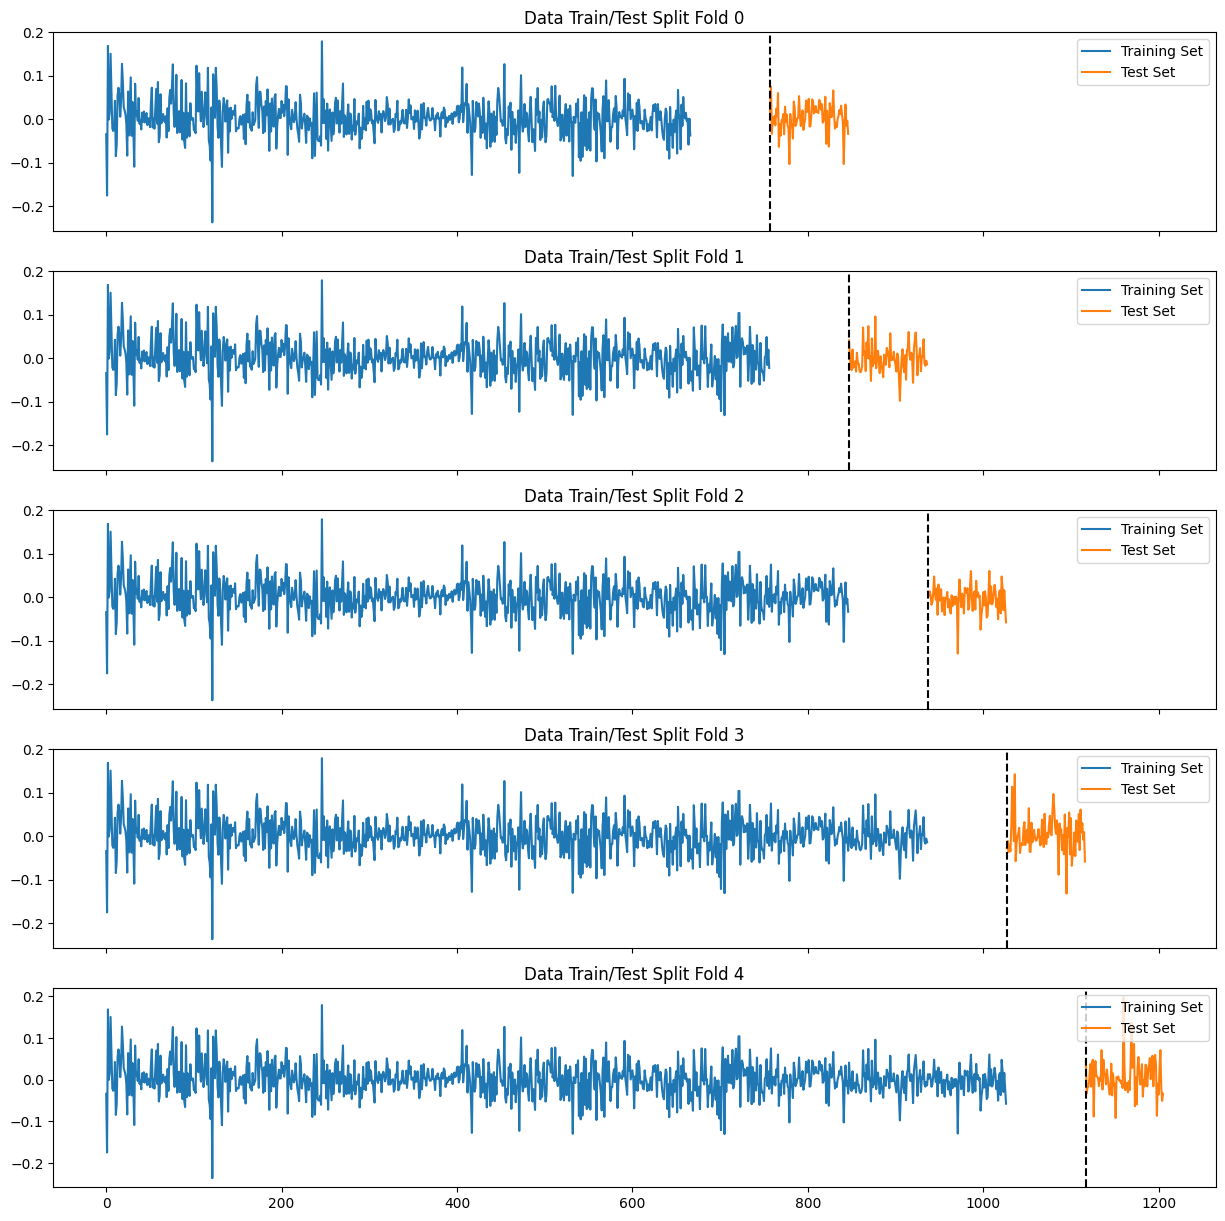

In [50]:
# Visualize each fold in TimeSeriesSplit CV
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

for fold in folds: 
    k = fold["fold"]
    train_idx = fold["train_idx"]
    test_idx  = fold["test_idx"]

    train = tesla.iloc[train_idx]
    test  = tesla.iloc[test_idx]

    ax = axs[k]
    train['next_day_return'].plot(ax=ax,label="Training Set", title=f"Data Train/Test Split Fold {k}")
    test['next_day_return'].plot(ax=ax, label="Test Set")
    ax.legend(loc="upper right")
    ax.axvline(test.index.min(), color="black", ls="--")

plt.show()